### 0. 开始

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import osmnx as ox
import utils_z
import os

In [3]:
conn = utils_z.get_conn("Test20260413", "postgres", "we6666", "localhost", "5432")

### 1. 处理pbf并导入数据库

#### 1.1 通过城市名称获得city边界

In [4]:
# 通过城市名称获得city边界
country_pbf_name = "berlin-260412.osm.pbf"
pbf_filepath = f"E:\\2_data\\geofabrik_downloads\\{country_pbf_name}"

city_query_name = "Berlin, Germany"
city_name = "berlin"

CURRENT PROCESSING CITY: Berlin, Germany
      display_name  osm_id  osm_type
0  Berlin, Germany   62422  relation
crs: epsg:4326
geo type: ['MultiPolygon']

城市轮廓面积：890.69 km²
Bounding Box (minx, miny, maxx, maxy): [13.088345  52.3382448 13.7611609 52.6755087]


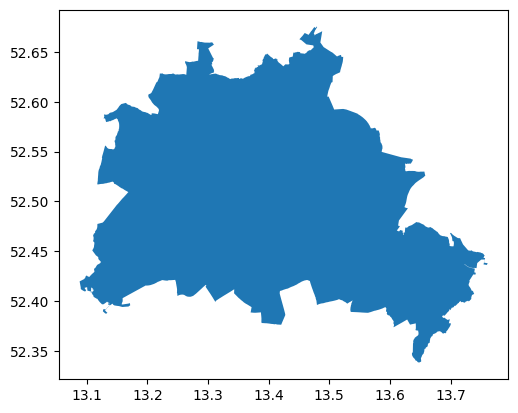

In [5]:
city = ox.geocode_to_gdf(city_query_name)
print("CURRENT PROCESSING CITY: " + city_query_name)
print(city[["display_name", "osm_id", "osm_type"]])

# 检查结果
print(f"crs: {city.crs}")  
print(f"geo type: {city.geometry.type.values}")  # 应该是 MultiPolygon 或 Polygon
city.plot()

# 计算城市轮廓面积（平方千米）
# 转换为投影坐标系（使用 utm）以准确计算面积

city_utm = city.to_crs(city.estimate_utm_crs())
city_area_km2 = city_utm.geometry.area.sum() / 1_000_000  # 平方米转换为平方千米

print(f"\n城市轮廓面积：{city_area_km2:.2f} km²")

# 打印城市轮廓东西南北四个方向的极限经纬度
bbox = city.total_bounds
print(f"Bounding Box (minx, miny, maxx, maxy): {bbox}")

#### 1.2 提取城市边界并存储

In [6]:
bound_filename = city_name + "_boundary.geojson"
bound_filepath = "E:\\2_data\\block_data\\boundary\\" + bound_filename
city.to_file(bound_filepath, driver="GeoJSON")
print(city_name + " boundary has been saved")

berlin boundary has been saved


#### 1.3 使用 osmium 从 pbf 中提取边界内的 OSM 数据

In [7]:
# 定义路径
output_filename = city_name + ".osm.pbf"
output_filepath = f"E:\\2_data\\block_data\\city_clip\\{output_filename}"

osmium_path = "E:\\0_python_envs\\urbanCode\\Library\\bin\\osmium.exe"
cmd = f'"{osmium_path}" extract --strategy=smart --polygon {bound_filepath} {pbf_filepath} -o {output_filepath} --overwrite'
utils_z.run_cmd(cmd)

CompletedProcess(args='"E:\\0_python_envs\\urbanCode\\Library\\bin\\osmium.exe" extract --strategy=smart --polygon E:\\2_data\\block_data\\boundary\\berlin_boundary.geojson E:\\2_data\\geofabrik_downloads\\berlin-260412.osm.pbf -o E:\\2_data\\block_data\\city_clip\\berlin.osm.pbf --overwrite', returncode=0, stdout='', stderr='')

#### 1.4 使用osmium分离出路网

In [8]:
output_road_path = f"E:\\2_data\\block_data\\city_clip\\{city_name + "_road.osm.pbf"}"

In [9]:
cmd = f'"{osmium_path}" tags-filter {output_filepath} w/highway=motorway,motorway_link,trunk,trunk_link,primary,primary_link,secondary,secondary_link,tertiary,tertiary_link,residential,unclassified -o {output_road_path} --overwrite'
utils_z.run_cmd(cmd)

CompletedProcess(args='"E:\\0_python_envs\\urbanCode\\Library\\bin\\osmium.exe" tags-filter E:\\2_data\\block_data\\city_clip\\berlin.osm.pbf w/highway=motorway,motorway_link,trunk,trunk_link,primary,primary_link,secondary,secondary_link,tertiary,tertiary_link,residential,unclassified -o E:\\2_data\\block_data\\city_clip\\berlin_road.osm.pbf --overwrite', returncode=0, stdout='', stderr='')

#### 1.5使用 osm2pgsql 将裁剪分离后的路网数据导入 PostgreSQL 数据库

In [10]:
osm2pgsql_path = "osm2pgsql"
osm2pgsql_default_style = "D:\\workSoftware\\PostgreSQL_Addon\\osm2pgsql-bin\\default.style"

os.environ["PGPASSWORD"] = "we6666"

cmd = f'{osm2pgsql_path} --schema=osm_import -c --drop -d Test20260413 -U postgres -H localhost --slim -C 4000 --style={osm2pgsql_default_style} {output_road_path}'

utils_z.run_cmd(cmd)

2026-04-27 15:20:13  osm2pgsql version 2.2.0 (2.2.0)
2026-04-27 15:20:13  Database version: 18.1
2026-04-27 15:20:13  PostGIS version: 3.6
2026-04-27 15:20:13  WARNING: The pgsql (default) output is deprecated. For details see https://osm2pgsql.org/doc/faq.html#the-pgsql-output-is-deprecated-what-does-that-mean
2026-04-27 15:20:13  Initializing properties table '"osm_import"."osm2pgsql_properties"'.
2026-04-27 15:20:13  Storing properties to table '"osm_import"."osm2pgsql_properties"'.
2026-04-27 15:20:13  Setting up table 'planet_osm_point'
2026-04-27 15:20:13  Setting up table 'planet_osm_line'
2026-04-27 15:20:13  Setting up table 'planet_osm_polygon'
2026-04-27 15:20:14  Setting up table 'planet_osm_roads'

Processing: Node(278k 278.0k/s) Way(29k 29.00k/s) Relation(0 0.0/s)
                                                                                          
2026-04-27 15:20:16  Reading input files done in 2s.
2026-04-27 15:20:16    Processed 278664 nodes in 0s - 279k/s
2026-0

CompletedProcess(args='osm2pgsql --schema=osm_import -c --drop -d Test20260413 -U postgres -H localhost --slim -C 4000 --style=D:\\workSoftware\\PostgreSQL_Addon\\osm2pgsql-bin\\default.style E:\\2_data\\block_data\\city_clip\\berlin_road.osm.pbf', returncode=0, stdout='', stderr='2026-04-27 15:20:13  osm2pgsql version 2.2.0 (2.2.0)\n2026-04-27 15:20:13  Database version: 18.1\n2026-04-27 15:20:13  PostGIS version: 3.6\n2026-04-27 15:20:13  WARNING: The pgsql (default) output is deprecated. For details see https://osm2pgsql.org/doc/faq.html#the-pgsql-output-is-deprecated-what-does-that-mean\n2026-04-27 15:20:13  Initializing properties table \'"osm_import"."osm2pgsql_properties"\'.\n2026-04-27 15:20:13  Storing properties to table \'"osm_import"."osm2pgsql_properties"\'.\n2026-04-27 15:20:13  Setting up table \'planet_osm_point\'\n2026-04-27 15:20:13  Setting up table \'planet_osm_line\'\n2026-04-27 15:20:13  Setting up table \'planet_osm_polygon\'\n2026-04-27 15:20:14  Setting up tabl

#### 1.6 使用 SQL 查询确认数据已成功导入，并检查坐标系

In [11]:
# 第一步：确认坐标系
sql_draw_check = "SELECT ST_SRID(way) FROM osm_import.planet_osm_line LIMIT 1;"
result = utils_z.run_sql(sql_draw_check, fetch=True, conn=conn)
print(f"当前坐标系SRID：{result[0][0]}")

当前坐标系SRID：3857


### 2. 使用 PostGIS 切割 Block

#### 2.1 使用 ST_Polygonize 切割 Block
* 统一编码4326
* noded道路交叉点
* 面积筛选大于1000
* 创建新表

In [12]:
city_label, country_label = city_query_name.split(", ")
city_prefix  = "DE_BE"
target_srid   = 4326

block_table_name = city_name + "_blocks"
block_table_name_full = "blocks." + block_table_name

In [13]:
sql_create_blocks = f"""
CREATE TABLE IF NOT EXISTS {block_table_name_full} AS
WITH
roads AS (
    SELECT ST_Transform(way, {target_srid}) AS geom
    FROM osm_import.planet_osm_line
    WHERE highway IN (
        'motorway', 'motorway_link',
        'trunk', 'trunk_link',
        'primary', 'primary_link',
        'secondary', 'secondary_link',
        'tertiary', 'tertiary_link',
        'residential', 'unclassified'
    )
),
noded AS (
    SELECT ST_Node(ST_Collect(geom)) AS geom FROM roads
),
polygonized AS (
    SELECT (ST_Dump(ST_Polygonize(geom))).geom AS geom FROM noded
)
SELECT
    '{city_prefix}_' || LPAD(ROW_NUMBER() OVER ()::TEXT, 6, '0') AS block_id,
    '{city_label}'  AS city,
    '{country_label}' AS country,
    ST_Area(geom::geography) AS area_m2,   -- 单位平方米
    geom,
    ST_Centroid(geom) AS centroid          -- 添加中心点字段
FROM polygonized
WHERE ST_Area(geom::geography) > 1000;
"""

utils_z.run_sql(sql_create_blocks, conn=conn)
print(f"{block_table_name_full} 表创建完成")

utils_z.run_sql(f"ALTER TABLE {block_table_name_full} ADD PRIMARY KEY (block_id);", conn=conn)
utils_z.run_sql(f"CREATE INDEX {block_table_name}_geom_idx ON {block_table_name_full} USING GIST (geom);", conn=conn)
print("索引创建完成")

blocks.berlin_blocks 表创建完成
索引创建完成


In [14]:
# 查询并打印 block 的总数
result = utils_z.run_sql(f"SELECT COUNT(*) FROM {block_table_name_full};", fetch=True, conn=conn)
total_blocks = result[0][0]
print(f"Total number of blocks created: {total_blocks}")

Total number of blocks created: 11999


#### 2.2 面积检查

In [31]:
# 检查Block的面积分布
result = utils_z.run_sql(f"""
SELECT
    COUNT(*) AS total,
    COUNT(*) FILTER (WHERE ST_Area(geom::geography) > 200000) AS oversized,
    MIN(ST_Area(geom::geography)) AS min_area,
    MAX(ST_Area(geom::geography)) AS max_area,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY ST_Area(geom::geography)) AS median_area,
    PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY ST_Area(geom::geography)) AS p95_area
FROM {block_table_name_full};
""", fetch=True,conn=conn)

print(f"总Block数：{result[0][0]}")
print(f"超大Block数（>20公顷）：{result[0][1]}")
print(f"最小面积：{result[0][2]:.0f}㎡")
print(f"最大面积：{result[0][3]:.0f}㎡")
print(f"中位数面积：{result[0][4]:.0f}㎡")
print(f"95分位面积：{result[0][5]:.0f}㎡")

总Block数：998
超大Block数（>20公顷）：115
最小面积：1009㎡
最大面积：6505886㎡
中位数面积：20651㎡
95分位面积：517201㎡


In [ ]:
result = utils_z.run_sql(f"""
SELECT
    CASE
        WHEN ST_Area(geom::geography) < 5000 THEN '< 0.5公顷'
        WHEN ST_Area(geom::geography) < 10000 THEN '0.5–1公顷'
        WHEN ST_Area(geom::geography) < 50000 THEN '1–5公顷'
        WHEN ST_Area(geom::geography) < 100000 THEN '5–10公顷'
        WHEN ST_Area(geom::geography) < 200000 THEN '10–20公顷'
        WHEN ST_Area(geom::geography) < 500000 THEN '20–50公顷'
        WHEN ST_Area(geom::geography) < 1000000 THEN '50–100公顷'
        ELSE '> 100公顷'
    END AS area_range,
    COUNT(*) AS count
FROM {block_table_name_full}
GROUP BY area_range
ORDER BY MIN(ST_Area(geom::geography));
""", fetch=True, conn=conn)

for row in result:
    print(f"{row[0]}: {row[1]}个")

< 0.5公顷: 368个
0.5–1公顷: 377个
1–5公顷: 611个
5–10公顷: 119个
10–20公顷: 59个
20–50公顷: 31个
50–100公顷: 4个
> 100公顷: 4个


In [ ]:
# 检查 centroid 字段
print("=== 检查 Block Centroid ===")
result = utils_z.run_sql(f"""
    SELECT 
        block_id,
        ST_X(centroid::geometry) AS lon,
        ST_Y(centroid::geometry) AS lat,
        ST_Area(geom::geography) AS area_sqm
    FROM {block_table_name_full}
    LIMIT 10;
""", fetch=True, conn=conn)

print(f"\n前10个 blocks 的中心点坐标：")
print(f"{'Block ID':<15} {'经度':<15} {'纬度':<15} {'面积(m²)':<15}")
print("-" * 60)
for block_id, lon, lat, area in result:
    print(f"{str(block_id):<15} {lon:<15.6f} {lat:<15.6f} {area:<15.2f}")


=== 检查 Block Centroid ===

前10个 blocks 的中心点坐标：
Block ID        经度              纬度              面积(m²)         
------------------------------------------------------------
CH_ZU_000001    8.470692        47.388392       1624.72        
CH_ZU_000002    8.473604        47.387512       73156.89       
CH_ZU_000003    8.479755        47.371393       343358.43      
CH_ZU_000004    8.471915        47.390924       82918.83       
CH_ZU_000005    8.473429        47.386670       2460.56        
CH_ZU_000006    8.472240        47.394687       8409.58        
CH_ZU_000007    8.474672        47.388579       42999.84       
CH_ZU_000008    8.476073        47.392396       8173.29        
CH_ZU_000009    8.473360        47.394127       7109.78        
CH_ZU_000010    8.482920        47.392805       282777.97      


#### 2.3 绘制检查

In [17]:
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
import py5

In [ ]:
sql_draw_check = f"""
      SELECT row_number() OVER () AS rid, geom
      FROM {block_table_name_full}
      ORDER BY geom; \
      """
gdf = gpd.read_postgis(sql_draw_check, conn, geom_col="geom", crs="EPSG:3857")
blocks_draw = list(gdf.geometry)

print(f"Loaded {len(blocks_draw)} blocks")

e:\0_python_envs\urbanCode\Lib\site-packages\geopandas\io\sql.py:185: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


Loaded 4998 blocks


In [19]:
def all_polygons(g):
    """把 MultiPolygon 统一展开成 Polygon 列表"""
    if isinstance(g, Polygon):
        return [g]
    elif isinstance(g, MultiPolygon):
        return list(g.geoms)
    return []

def draw_block(poly):
    """把 polygon 缩放并居中到屏幕绘制"""

    # 窗口大小
    W, H = py5.width, py5.height

    minx, miny, maxx, maxy = poly.bounds
    cw = maxx - minx
    ch = maxy - miny

    # 留一点边距
    margin = 0.15
    scale = min((W * (1 - margin)) / cw, (H * (1 - margin)) / ch)

    # 居中偏移量
    cx = (minx + maxx) / 2
    cy = (miny + maxy) / 2

    py5.push_matrix()
    py5.translate(W / 2, H / 2)
    py5.scale(scale, -scale)   # y 轴反向，方便直观
    py5.translate(-cx, -cy)

    py5.fill(210)
    py5.stroke(0)

    for p in all_polygons(poly):
        coords = list(p.exterior.coords)

        py5.begin_shape()
        for x, y in coords:
            py5.vertex(x, y)
        py5.end_shape(py5.CLOSE)

    py5.pop_matrix()

In [20]:
# py5显示

current = 0

def setup():
    py5.size(900, 700)
    py5.text_size(16)
    py5.text_align(py5.CENTER, py5.CENTER)


def draw():
    py5.background(255)

    global current
    b = blocks_draw[current]
    area = b.area   # m²（EPSG:3857）

    draw_block(b)

    py5.fill(0)
    py5.text(
        f"Block {current+1}/{len(blocks_draw)} — Area: {area:,.0f} m²\nPress 1 = next, q = quit",
        py5.width/2,
        30
    )


def key_pressed():
    global current

    if py5.key == '1':
        current = (current + 1) % len(blocks_draw)

    if py5.key == 'q':
        py5.exit_sketch()


py5.run_sketch()

### 3. 一些临时处理

> 给当前已有的表格增加中心经纬度坐标字段

In [ ]:
for table in ["hamburg_blocks", "vienna_blocks", "amsterdam_blocks"]:
    utils_z.run_sql(f"""
        ALTER TABLE {table}
        ADD COLUMN IF NOT EXISTS centroid GEOMETRY(Point, 4326);
    """, conn=conn)
    
    utils_z.run_sql(f"""
        UPDATE {table}
        SET centroid = ST_Centroid(geom);
    """, conn=conn)
    
    utils_z.run_sql(f"""
        CREATE INDEX IF NOT EXISTS {table}_centroid_idx
        ON {table} USING GIST (centroid);
    """, conn=conn)
    
    print(f"{table} centroid添加完成")

hamburg_blocks centroid添加完成
vienna_blocks centroid添加完成
amsterdam_blocks centroid添加完成


In [ ]:
# 验证
for table in ["hamburg_blocks", "vienna_blocks", "amsterdam_blocks"]:
    result = utils_z.run_sql(f"""
        SELECT block_id, ST_AsText(centroid) 
        FROM {table} LIMIT 2;
    """, conn=conn, fetch=True)
    print(f"{table}: {result}")

hamburg_blocks: [('DE_HH_003753', 'POINT(10.028629071961976 53.5174871946387)'), ('DE_HH_000004', 'POINT(9.744554517711626 53.58411976642328)')]
vienna_blocks: [('AT_VI_001260', 'POINT(16.312693953578112 48.22420853161371)'), ('AT_VI_003589', 'POINT(16.366378333654687 48.23417352978996)')]
amsterdam_blocks: [('NL_AM_001502', 'POINT(4.855759088806063 52.36259229392457)'), ('NL_AM_000026', 'POINT(4.767504330210546 52.39590595981949)')]
